In [2]:
import numpy as np
import sys
import os
from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


In [3]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'

In [4]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [5]:
data = np.load(data_dir + 'h2o_dynamic_centered.npy', allow_pickle=True).item()
npy_pos = data['positions'][:10]
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + (4.1483 / 2))
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)
print('lattice shape', lattice.shape)
print('metric shape', metric.shape)

gap = 0.155
grid = MakeGrid(metric,gap)

pos shape (10, 3, 3)
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [2.47061852 3.39651439 2.67979421]
 [4.35281594 5.21629046 3.14811936]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [5.10267249 2.94568056 2.24997598]
 [4.92288399 4.96707521 5.00262654]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [4.2195014  5.84419161 3.8650644 ]
 [1.97577301 4.7907429  4.05095297]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [3.40724994 4.26058786 2.19654778]
 [3.00509167 5.43900224 3.59987348]]
                 nat : 3
                   Z : [8 1 1]
            

In [6]:
print('ions zval', ions.Zval)
print('ions labels', ions.labels)

ions zval {}
ions labels ['O' 'H' 'H']


In [7]:
path_pp = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/'
file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
             'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: path_pp+file_names[key] for key in file_names.keys()}
print(PP_list)
PSEUDO = LocalPseudo(grid = grid, ions=None, PP_list=PP_list,PME=True)

{'H': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/H.pbe-kjpaw_psl.0.1.UPF', 'C': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/C.pbe-kjpaw_psl.0.1.UPF', 'O': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/O.pbe-n-kjpaw_psl.0.1.UPF'}
setting key: H
setting key: C
setting key: O


In [8]:
init_rhos = []
for ions in ions_list:
    PSEUDO.restart(grid=grid, ions=ions)
    rho_ini = guess_rho(grid, ions)
    init_rhos.append(rho_ini)

#rho_ini = guess_rho(grid,ions)

In [9]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [10]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat


In [11]:
opt_rhos = []
for i in range(len(init_rhos)):
    rho = init_rhos[i]
    ions = ions_list[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')

    new_rho = opt.optimize_rho(guess_rho=rho)
    opt_rhos.append(new_rho)

evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.495135381679092
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786297
evalfunctional HARTREE
evalfunctional HARTREE
energy 9.812258905963942e-34
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476564
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.599061E+00    1       1       1.621127E-01    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6073504171626405
evalfunctional XC
evalfunctional LDA
energy -1.8547304186066016
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.04814747502819471
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.8260353407583438
evalfunctional KEDF
evalfunctional x_TF_y_

energy -3.3264240178753077
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.4817081455347045
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.54411205940616
4       -1.128216387865E+01     -2.800047E-03   1.526198E-02    13      1       3.467618E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
e

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

energy 9.976449972428767
evalfunctional XC
evalfunctional LDA
energy -3.296568893357794
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.307263893554826
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.59448050998783
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.770550224922586
evalfunctional XC
evalfunctional LDA
energy -3.260078005443592
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.121156711829123
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.243467493150515
3       -1.061183856184E+01     -1.394258E-02   8.996910E-02    16      2       2.707251E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfuncti

...

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.75961426854164
evalfunctional XC
evalfunctional LDA
energy -3.2633440379388303
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.145434695403171
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.365026496004038
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.794735034988943
evalfunctional XC
evalfunctional LDA
energy -3.2706522367015283
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.181100960797237
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.428984419494025
5       -1.072380066041E+01     -1.617013E-03   4.432869E-03    16      2       5.697169E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunc

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.784542986547434
evalfunctional XC
evalfunctional LDA
energy -3.2683445258309267
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.168487821052407
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.408646268673966
8       -1.072395998691E+01     -6.620565E-07   1.202305E-04    17      1       9

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.90559014677887
evalfunctional XC
evalfunctional LDA
energy -3.293819215087781
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.302651841426041
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.8476451911

In [12]:
mols = []
for i in range(len(opt_rhos)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    Enew = E_v_Evaluator.Energy(rho=opt_rho, ions=ions, usePME = True)
    mol = System(ions,cell=grid,name='test',field=opt_rho)
    mols.append(mol)

    print('Energy New (a.u.)', Enew)
    print('Energy New (eV)', Enew * ENERGY_CONV['Hartree']['eV'])
    print('Energy New (eV/atom)', Enew * ENERGY_CONV['Hartree']['eV']/ions.nat)
    print('-' * 31, 'Time information', '-' * 31)
    print("{:28s}{:24s}{:20s}".format('Label', 'Cost(s)', 'Number'))
    for key in TimeData.cost :
        print("{:28s}{:<24.4f}{:<20d}".format(key, TimeData.cost[key], TimeData.number[key]))
    print('-' * 80)

Ewald : -4.1587612704638985
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.155139277908049
evalfunctional XC
evalfunctional LDA
energy -3.3359189616673834
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.527129490187082
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.630304272890882
Energy New (a.u.) -15.442715736927033
Energy New (eV) -420.2176590857582
Energy New (eV/atom) -140.07255302858607
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    176.9292                10                  
TF                          22.7303                 4296                
vW                          50.3754                 4296                
FFT                         28.3309                 8626                
InvFFT                      32.1602                 8603                
LDA                         42.1759                 4296      

energy -24.766782696304503
Energy New (a.u.) -15.393854575354517
Energy New (eV) -418.8880792834754
Energy New (eV/atom) -139.62935976115847
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    176.9292                10                  
TF                          22.7610                 4306                
vW                          50.4437                 4306                
FFT                         28.4091                 8666                
InvFFT                      32.2107                 8628                
LDA                         42.2227                 4306                
Hartree_Func                46.7708                 4306                
Vion_PME                    1.3214                  16                  
Ewald_Energy                0.0833                  6                   
Ewald_Energy_Real           0.0359              

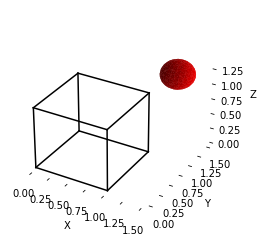

In [13]:
from dftpy.visualize.jupyter import view_density
view_density(mols[0])

In [15]:

for i in range(len(ions_list)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    print('ENERGY new', en_calc.Energy(rho=opt_rho, ions=ions, usePME=False))
    print('ENERGY init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

L [7.83915089 7.83915089 7.83915089]
Ewald : -4.158761270380737
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.155139277908049
evalfunctional XC
evalfunctional LDA
energy -3.3359189616673834
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.527129490187082
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.630304272890882
ENERGY new -15.442715736843871
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.158761270380737
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.495135381679092
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786297
evalfunctional HARTREE
evalfunctional HARTREE
energy 4.932107445546928e-34
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764344
ENERGY init -4.44253968930551
L [7.83915089 7.83915089 7.83915089]
Ewald : -5.072169409584472
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.725341511265032
evalfunctional XC
evalfunctional LDA
energy -3.2544390534279697
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.

In [15]:
from equiv_dens.training.grids import CubicalGrid
cube_dim = 50
grid_cl = CubicalGrid(None, nx=cube_dim, ny=cube_dim, nz=cube_dim, origin=[0, 0, 0], extent=np.diag(grid.lattice))
#print(grid_cl.coords)

In [16]:
from equiv_dens.nn.density_functionals.LDA import LDAFunctional
import torch
z_vals = []
for t in data['atom_types']:
    z_vals.append(ions.Zval[t])
z_vals = np.array(z_vals)
print(data['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals)
#print('rho ini', rho_ini)
for i in range(5,6):
    ions = ions_list[i]
    opt_rho = torch.tensor(opt_rhos[i])
    rho_ini = torch.tensor(init_rhos[i])
    #print('rho tensor', rho)
    pos = torch.tensor(ions.pos)
    PSEUDO.restart(grid=grid, ions=ions)
    print(lda(rho_ini, grid_cl, pos, PSEUDO))
    print(lda(opt_rho, grid_cl, pos, PSEUDO))

[8 1 1]
[6. 1. 1.]
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.0172, dtype=torch.float64)
thomas fermi energy tensor(1.4951, dtype=torch.float64)
pot type torch.DoubleTensor
rho type torch.DoubleTensor
von weizsacker energy tensor(2.3739e-31, dtype=torch.float64)
tf_vw en tensor(1.4951, dtype=torch.float64)
lda energy tensor(-1.8372, dtype=torch.float64)
hartree energy tensor(7.4194e-33, dtype=torch.float64)
pseudo energy tensor(0.0582, dtype=torch.float64)
tensor(-4.3010, dtype=torch.float64)
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.0172, dtype=torch.float64)
thomas fermi energy tensor(7.1008, dtype=torch.float64)
pot type torch.DoubleTensor
rho type torch.DoubleT

In [17]:
import torch.autograd as grad
import time
start = time.time()
opt_rho = torch.tensor(opt_rhos[0])
ions = ions_list[0]
pos = torch.tensor(ions.pos)
PSEUDO.restart(grid=grid, ions=ions)
opt_rho.requires_grad = True
en = lda(opt_rho, grid_cl, pos, PSEUDO)
#print('rho grad', opt_rho.grad)
#en.backward()
#print('rho grad', opt_rho.grad)
print(en)
print(time.time() - start)


rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.1588, dtype=torch.float64)
thomas fermi energy tensor(7.0772, dtype=torch.float64, grad_fn=<AsStridedBackward>)
pot type torch.DoubleTensor
rho type torch.DoubleTensor
von weizsacker energy tensor(3.0779, dtype=torch.float64, grad_fn=<MulBackward0>)
tf_vw en tensor(10.1551, dtype=torch.float64, grad_fn=<AddBackward0>)
lda energy tensor(-3.3359, dtype=torch.float64, grad_fn=<MulBackward0>)
hartree energy tensor(6.5271, dtype=torch.float64, grad_fn=<DivBackward0>)
pseudo energy tensor(-24.6303, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(-15.4427, dtype=torch.float64, grad_fn=<AddBackward0>)
0.1289048194885254


In [18]:
print('integral = ', torch.sum(opt_rho) * grid.dV)

integral =  tensor(8.0000, dtype=torch.float64, grad_fn=<MulBackward0>)


In [19]:
import torch.fft as tfft
opt_rho = torch.tensor(opt_rhos[0])
opt_rho.requires_grad = True
fft_rho = tfft.rfftn(opt_rho)
ss = torch.sum(fft_rho)
ss.backward()
print(opt_rho.grad)
    

tensor([[[ 6.5000e+04, -1.1937e-12,  2.5000e+03,  ..., -9.5967e-13,
           2.5000e+03,  1.0590e-12],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0

In [27]:
from equiv_dens.training.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.training.grids import cubical_grid, cubical_sampling

directory = '2020-10-15_8gYN9fzi'  # load directory name
model_name = '8gYN9fzi'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [28]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'

cube_grid_fn = partial(cubical_grid, nx=cube_dim, ny=cube_dim, nz=cube_dim,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318 , -2.0318]))
cube_sampling_fn = cubical_sampling

valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                                      orbitals_path=args.orbitals_file,
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file=args.radial_coeffs_file,
                                      dtype=args.dtype,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

loading density fromdatasets/h2o_dynamic_pyscf_dft.npy...
loading atoms fromdatasets/h2o_dynamic_centered.npy...
Starting atomsdata density init
Some variables
finished init


density shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
density shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]


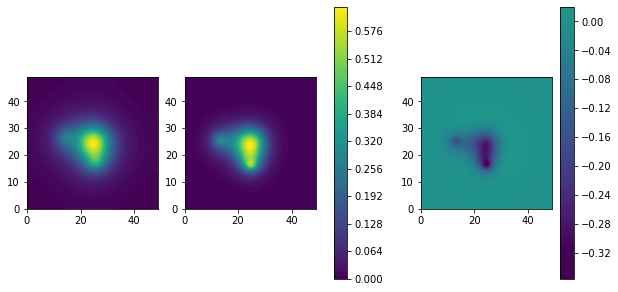

[[3.91957544 3.91957544 3.91957544]
 [2.16767095 4.15899805 2.9744327 ]
 [4.03705215 2.68404984 3.05287341]]


In [29]:
import matplotlib.pyplot as plt
sample = 5

dens_opt = opt_rhos[sample]
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens_opt = np.array(dens_opt)
dens_opt = dens_opt.reshape((cube_dim**3, ))
print('density shape', dens_opt.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens_opt[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

dens_data = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('density shape', dens_data.shape)

ax2 = fig.add_subplot(132)
print('idx', idx)
densd2d = dens_data[idx]
densd2d = densd2d.reshape(cube_dim, cube_dim)

vmin = np.min(densd2d)
vmax = np.max(densd2d)
c2 = ax2.contourf(x, y, densd2d, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, dens2d-densd2d, vmin=-vmax/2, vmax=vmax/2, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()
print(ions_list[sample].pos)

In [23]:
print(npy_pos[sample])

[[ 0.          0.          0.        ]
 [-0.92706794  0.12669699 -0.500148  ]
 [ 0.062166   -0.653812   -0.45863897]]


pseudo shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]


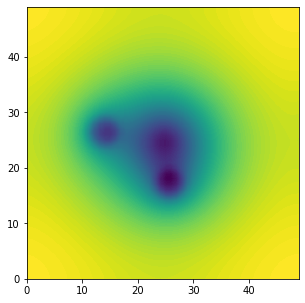

In [30]:
from equiv_dens.training.grids import CubicalGrid

PSEUDO.restart(grid=grid, ions=ions_list[sample])
dens = opt_rhos[5]
PSEUDO(dens)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(PSEUDO.vreal)
pot = pot.reshape((cube_dim**3, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')